# ***Intro:***

A Support Vector Machine (SVM) is a discriminative classifier formally defined by a separating hyperplane. In other words, given labeled training data (supervised learning), the algorithm outputs an optimal hyperplane which categorizes new examples. In two dimentional space this hyperplane is a line dividing a plane in two parts where in each class lay in either side.

Now I want to alk about one concept that we will use alot.

***Kernel Function*** is a method used to take data as input and transform it into the required form of processing data. **“Kernel”** is used due to a set of mathematical functions used in Support Vector Machine providing the window to manipulate the data. So, Kernel Function generally transforms the training set of data so that a non-linear decision surface is able to transform to a linear equation in a higher number of dimension spaces. Basically, It returns the inner product between two points in a standard feature dimension.
Some examples:

* **Gaussian Kernel:** It is used to perform transformation when there is no prior knowledge about data.
* **Gaussian Kernel Radial Basis Function (RBF):** Same as above kernel function, adding radial basis method to improve the transformation.

In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel ='rbf', random_state = 0)  #Training set in x, y axis
classifier.fit(x_train, y_train)

* **Sigmoid Kernel:** this function is equivalent to a two-layer, perceptron model of the neural network, which is used as an activation function for artificial neurons.

In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel ='sigmoid')
classifier.fit(x_train, y_train)

* **Polynomial Kernel:** It represents the similarity of vectors in the training set of data in a feature space over polynomials of the original variables used in the kernel.

In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel ='poly', degree = 4)
classifier.fit(x_train, y_train)

* **Linear Kernel:** used when data is linearly separable.

In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel ='linear')
classifier.fit(x_train, y_train)

In the following implementation I want to use linear kernel.

# ***Implementation:***

LinearSVC:                    [0.28475098] [[1.05364854 1.09903804]]
SVC:                          [0.31896852] [[1.1203284  1.02625193]]
SGDClassifier(alpha=0.00100): [0.117] [[0.77735075 0.73012524]]


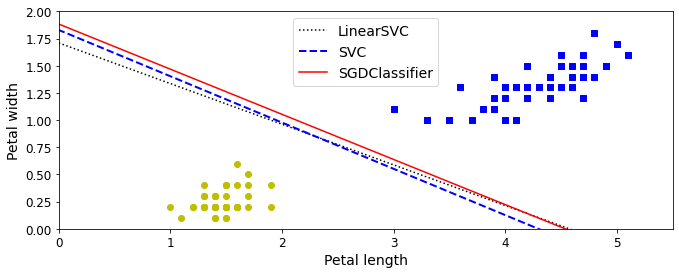

In [ ]:
#First : Hyperplanes
#We assume here that our data set can be well separated into two domains. In this case the datas are represented either by square or circle.
#The dataset I use here is the one that most of us already know : Iris dataset
from sklearn import datasets
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12


iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  #Petal length, Petal width
y = iris["target"]

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

C = 10 #In all cases consider overfitting
alpha = 1 / (C * len(X))

lin_clf = LinearSVC(loss="hinge", C=C, random_state=42)
svm_clf = SVC(kernel="linear", C=C)
sgd_clf = SGDClassifier(loss="hinge", learning_rate="constant", eta0=0.001, alpha=alpha,
                        max_iter=100000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lin_clf.fit(X_scaled, y)
svm_clf.fit(X_scaled, y)
sgd_clf.fit(X_scaled, y)

print("LinearSVC:                   ", lin_clf.intercept_, lin_clf.coef_)
print("SVC:                         ", svm_clf.intercept_, svm_clf.coef_)
print("SGDClassifier(alpha={:.5f}):".format(sgd_clf.alpha), sgd_clf.intercept_, sgd_clf.coef_)

#Compute the slope and bias of each decision boundary
w1 = -lin_clf.coef_[0, 0]/lin_clf.coef_[0, 1]
b1 = -lin_clf.intercept_[0]/lin_clf.coef_[0, 1]
w2 = -svm_clf.coef_[0, 0]/svm_clf.coef_[0, 1]
b2 = -svm_clf.intercept_[0]/svm_clf.coef_[0, 1]
w3 = -sgd_clf.coef_[0, 0]/sgd_clf.coef_[0, 1]
b3 = -sgd_clf.intercept_[0]/sgd_clf.coef_[0, 1]

#Transform the decision boundary lines back to the original scale
line1 = scaler.inverse_transform([[-10, -10 * w1 + b1], [10, 10 * w1 + b1]])
line2 = scaler.inverse_transform([[-10, -10 * w2 + b2], [10, 10 * w2 + b2]])
line3 = scaler.inverse_transform([[-10, -10 * w3 + b3], [10, 10 * w3 + b3]])

#Plot all three decision boundaries
plt.figure(figsize=(11, 4))
plt.plot(line1[:, 0], line1[:, 1], "k:", label="LinearSVC")
plt.plot(line2[:, 0], line2[:, 1], "b--", linewidth=2, label="SVC")
plt.plot(line3[:, 0], line3[:, 1], "r-", label="SGDClassifier")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs") #Label="Iris-Versicolor"
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo") #Label="Iris-Setosa"
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper center", fontsize=14)
plt.axis([0, 5.5, 0, 2])

plt.show()

# ***Second Implementation:***
So, What will happend if we can't split our data linearly?

In this case we need the higher dimentional kernel. But in all cases jsut consider overfitting and underfitting.
In the next implementation Let's work on nonlinear example:

In this case we need a transform function like the one that we saw in slides.

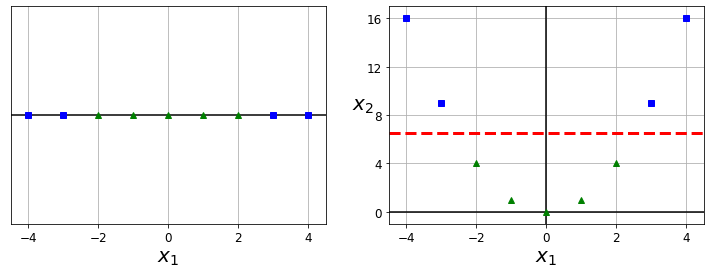

In [ ]:
import numpy as np
import os
from sklearn.svm import SVC
from sklearn import datasets
import matplotlib
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
X1D = np.linspace(-4, 4, 9).reshape(-1, 1)
X2D = np.c_[X1D, X1D**2]
y = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(11, 4))
plt.subplot(122)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(X2D[:, 0][y==0], X2D[:, 1][y==0], "bs")
plt.plot(X2D[:, 0][y==1], X2D[:, 1][y==1], "g^")
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"$x_2$", fontsize=20, rotation=0)
plt.gca().get_yaxis().set_ticks([0, 4, 8, 12, 16])
plt.plot([-4.5, 4.5], [6.5, 6.5], "r--", linewidth=3)
plt.axis([-4.5, 4.5, -1, 17])
plt.subplots_adjust(right=1)

plt.subplot(121)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.plot(X1D[:, 0][y==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][y==1], np.zeros(5), "g^")
plt.gca().get_yaxis().set_ticks([])
plt.xlabel(r"$x_1$", fontsize=20)
plt.axis([-4.5, 4.5, -0.2, 0.2])

plt.show()